# Load and prepare data

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the data
df = pd.read_csv('../data/hourly_fitbit_sema_df_unprocessed.csv')

# Convert date to datetime
df['date'] = pd.to_datetime(df['date'])

# Extract unique participant count
unique_participants = df['id'].nunique()
print(f"Total participants: {unique_participants}")

# Calculate study duration
study_duration = (df['date'].max() - df['date'].min()).days + 1
print(f"Study duration: {study_duration} days")


/var/folders/jr/fjq1bs050kn640mw57y5t5bm0000gp/T/ipykernel_79770/2404163616.py:7: DtypeWarning: Columns (9,19) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('../data/hourly_fitbit_sema_df_unprocessed.csv')


Total participants: 71
Study duration: 290 days


In [ ]:
# Add cohort column based on the date


# Analyse EMA completion

In [22]:
# Identify EMA response columns (the mood/affect columns)
ema_columns = ['ALERT', 'HAPPY', 'NEUTRAL', 'RESTED/RELAXED', 'SAD', 'TENSE/ANXIOUS', 'TIRED']

# Create a daily EMA response flag
df['ema_response'] = df[ema_columns].any(axis=1)

# Calculate daily EMA completion rates
daily_ema = df.groupby(['id', 'date'])['ema_response'].max().reset_index()
ema_completion_rate = daily_ema['ema_response'].mean()
print(f"Daily EMA completion rate: {ema_completion_rate:.2%}")


Daily EMA completion rate: 32.69%


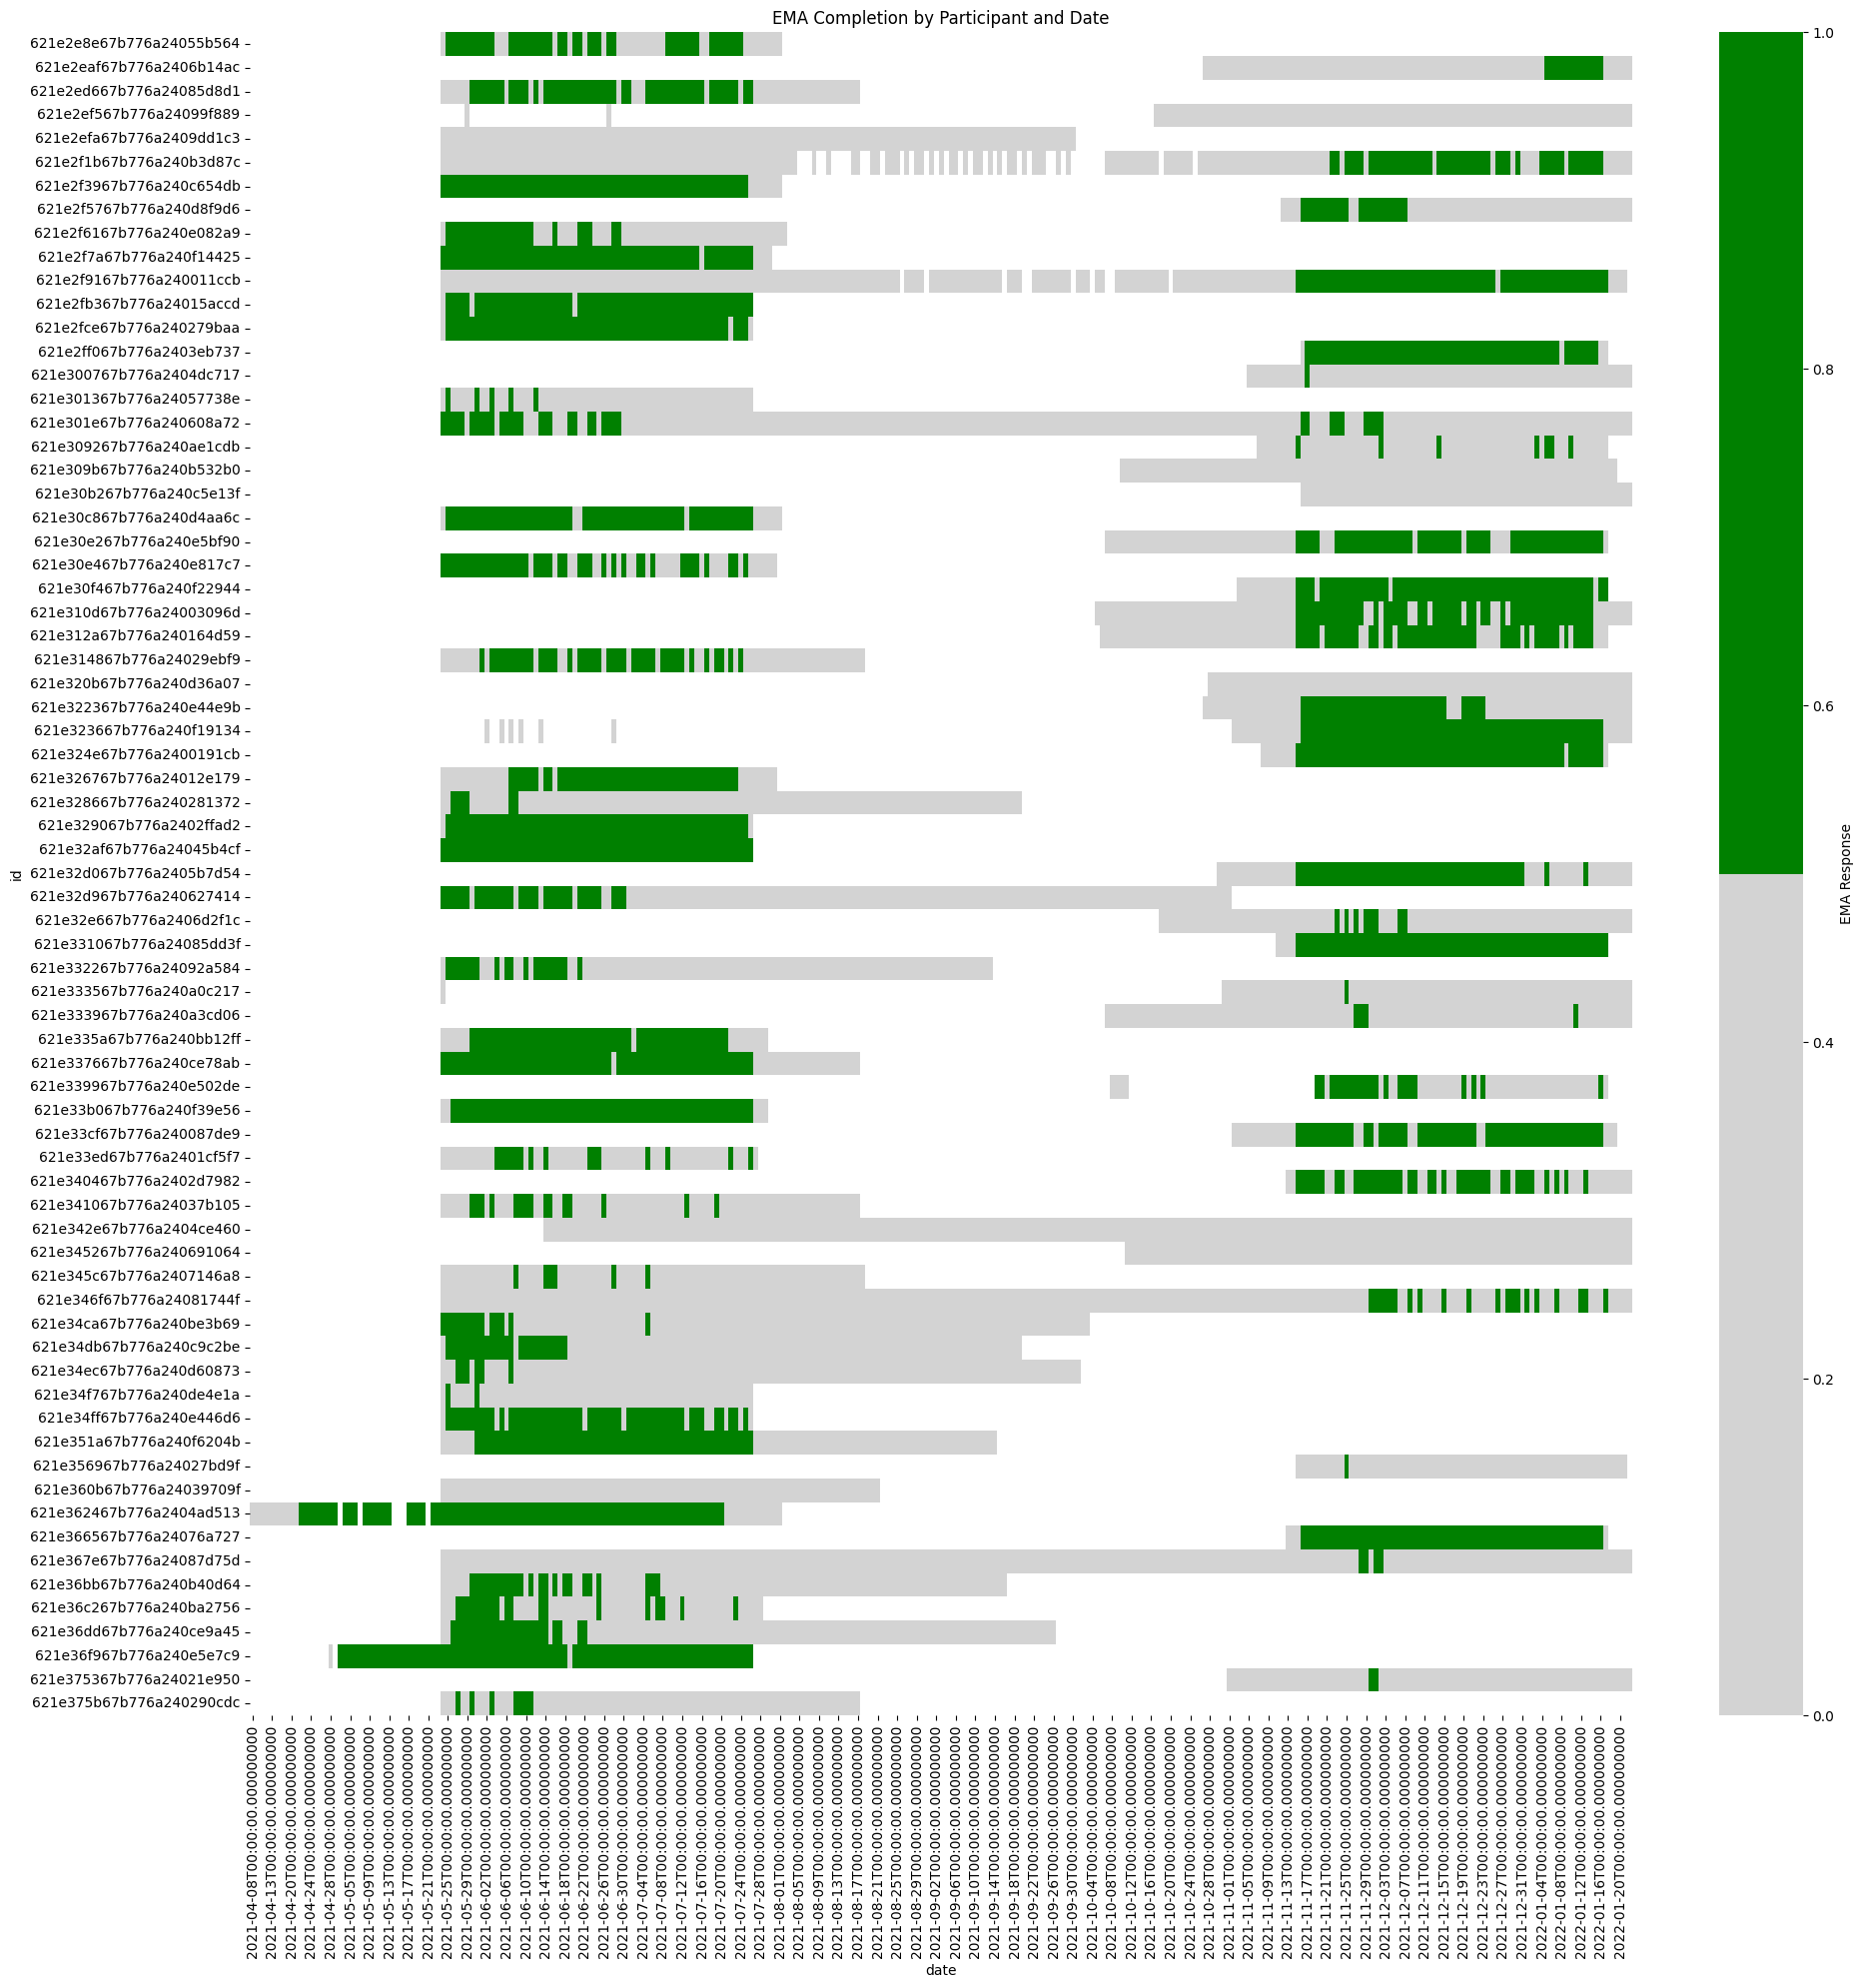

In [23]:
# EMA Completion Heatmap
plt.figure(figsize=(20, 20))
# Use pivot_table instead of pivot with correct argument names
heatmap_data = daily_ema.pivot_table(index='id', columns='date', values='ema_response')
sns.heatmap(heatmap_data, 
            cbar_kws={'label': 'EMA Response'},
            cmap=['lightgray', 'green'])  # False=gray, True=green
plt.title('EMA Completion by Participant and Date')
plt.tight_layout()
plt.show()


# Analyse Fitbit data completeness

Daily wearable data completeness:
temperature                     0.471663
calories                        0.950749
distance                        0.681941
activityType                    0.315917
bpm                             0.685796
mindfulness_session             0.954747
scl_avg                         0.062384
steps                           0.681941
minutes_in_default_zone_1       0.686224
minutes_below_default_zone_1    0.686224
minutes_in_default_zone_2       0.686224
minutes_in_default_zone_3       0.686224
dtype: float64


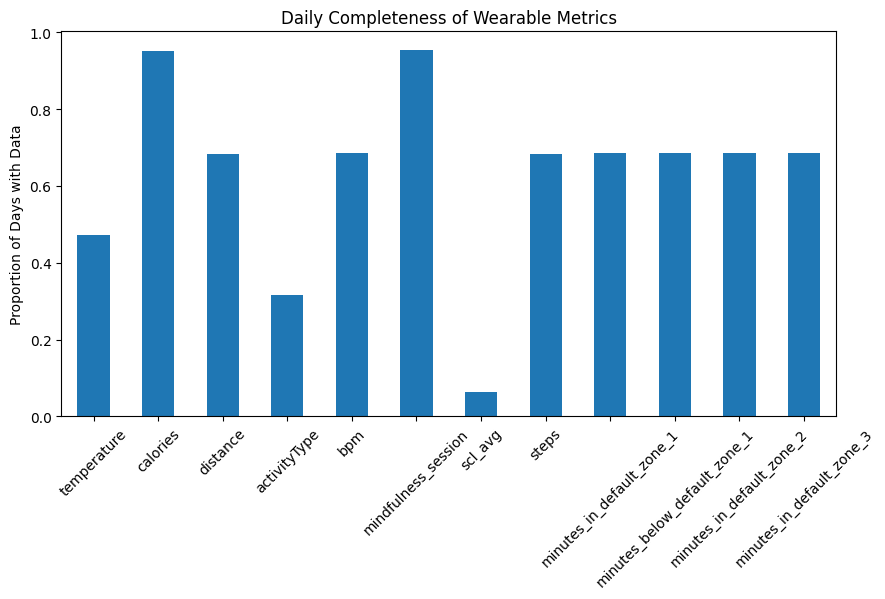

In [24]:
# Identify key wearable metrics
wearable_metrics = [
    'temperature', 'calories', 'distance', 
    'activityType', 'bpm', 'mindfulness_session', 'scl_avg', 
    'steps', 'minutes_in_default_zone_1', 'minutes_below_default_zone_1', 
    'minutes_in_default_zone_2', 'minutes_in_default_zone_3'
]

# Create daily completeness indicators
daily_wearable = df.groupby(['id', 'date'])[wearable_metrics].agg({
    'temperature': lambda x: x.notna().any(),
    'calories': lambda x: x.notna().any(),
    'distance': lambda x: x.notna().any(),
    'activityType': lambda x: x.notna().any(),
    'bpm': lambda x: x.notna().any(),
    'mindfulness_session': lambda x: x.notna().any(),
    'scl_avg': lambda x: x.notna().any(),
    'steps': lambda x: x.notna().any(),
    'minutes_in_default_zone_1': lambda x: x.notna().any(),
    'minutes_below_default_zone_1': lambda x: x.notna().any(),
    'minutes_in_default_zone_2': lambda x: x.notna().any(),
    'minutes_in_default_zone_3': lambda x: x.notna().any()
}).reset_index()

# Calculate overall wearable completeness
wearable_completeness = daily_wearable[wearable_metrics].mean()
print("Daily wearable data completeness:")
print(wearable_completeness)

# Visualize wearable completeness
plt.figure(figsize=(10, 5))
wearable_completeness.plot(kind='bar')
plt.title('Daily Completeness of Wearable Metrics')
plt.ylabel('Proportion of Days with Data')
plt.xticks(rotation=45)
plt.show()


# Joint Completeness (Fitbit + EMA)

In [29]:
# Merge EMA and wearable completeness
daily_completeness = pd.merge(
    daily_ema[['id', 'date', 'ema_response']],
    daily_wearable,
    on=['id', 'date']
)

# Define "complete" day: EMA response + at least 3 wearable metrics
daily_completeness['complete_day'] = (
    daily_completeness['ema_response'] & 
    (daily_completeness[wearable_metrics].sum(axis=1) >= 3)
)

# Calculate joint completeness
joint_completeness = daily_completeness['complete_day'].mean()
print(f"Joint EMA + wearable completeness: {joint_completeness:.2%}")

# Calculate usable participant-days
usable_days = daily_completeness['complete_day'].sum()
total_possible_days = df.groupby(['id', 'date']).ngroups
print(f"Usable participant-days: {usable_days}/{total_possible_days} ({usable_days/total_possible_days:.2%})")


Joint EMA + wearable completeness: 29.72%
Usable participant-days: 2082/7005 (29.72%)


In [32]:
daily_completeness


,id,date,ema_response,temperature,calories,distance,activityType,bpm,mindfulness_session,scl_avg,steps,minutes_in_default_zone_1,minutes_below_default_zone_1,minutes_in_default_zone_2,minutes_in_default_zone_3,complete_day
0,621e2e8e67b776a24055b564,2021-05-24,False,True,True,True,True,True,True,False,True,True,True,True,True,False
1,621e2e8e67b776a24055b564,2021-05-25,True,True,True,True,True,True,True,False,True,True,True,True,True,True
2,621e2e8e67b776a24055b564,2021-05-26,True,True,True,True,True,True,True,False,True,True,True,True,True,True
3,621e2e8e67b776a24055b564,2021-05-27,True,True,True,True,True,True,True,False,True,True,True,True,True,True
4,621e2e8e67b776a24055b564,2021-05-28,True,True,True,True,True,True,True,False,True,True,True,True,True,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7000,621e375b67b776a240290cdc,2021-08-13,False,False,True,False,False,False,True,False,False,False,False,False,False,False
7001,621e375b67b776a240290cdc,2021-08-14,False,False,True,False,False,False,True,False,False,False,False,False,False,False
7002,621e375b67b776a240290cdc,2021-08-15,False,False,True,False,False,False,True,False,False,False,False,False,False,False
7003,621e375b67b776a240290cdc,2021-08-16,False,False,True,False,False,False,True,False,False,False,False,False,False,False


In [34]:
# Unique participants with complete days
complete_participants = daily_completeness[daily_completeness['complete_day']]['id'].nunique()
print(f"Participants with at least one complete day: {complete_participants}/{unique_participants} ({complete_participants/unique_participants:.2%})")


Participants with at least one complete day: 61/71 (85.92%)
